## A TEST file to start to develope a race strattegy calculator that can beused for simracing

In [1]:
import math
import numpy as np 
import matplotlib.pyplot as plt
import numpy.random as random
import scipy.integrate as integ
plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)

Ideas that  I want included,

To Start:

    Make fuel Pit calculator

        Input of Track and Lap Time,
        fuel consumption rate per lap

    Then Tyre Pit Calculator

        Input tyre wear per lap (if possible) / tyre wear per stint

        have to think about what wearr percentage is the point that I need to come in? related to competition and pit length

    Then Cross correlate the two so that one pitstop satisfies both

    Then Undercut/Overcut Predictor
        
        input competitor data, or can consider time lose for overrcut and undercut scenarios. 

    Other Variables I want considered

        In pits length 
        track Temp,
        Safety Car Probability,
        weather

    Then all data needs to be  cross corerlatted

Other Features:

gui to input data
live data collection from sim for up to date predictions

Ideas for Implementation

    to Start consider minimising ooverall race time, so could use gradient decent for optimise ralatted rates. 






## Fuel Pit Calculator

should include a virtual energy calculator in this, and then have the calcualtor determine wether the virtual energy or the fuel dictates when to stop

In [2]:
def FuelCalc (fuelPerLap, fuelTank, lapTime='-1:00:000'):

    """ This is a simple stint length calculator based off of your fuel used per lap 
    and the size of the fuel tank in the car. The average lap time is only used to 
    convert the stint length from laps to time, which is useful for further strategy analysis.

    Input:
    ------------
    fuelPerLap: float
        the average fuel usage per lap, Works only when using the same units as fuelTank
    fuelTank: float
        The total amount of fuel put into the fuel tank at the start of the stint, uses same units as fuelPerLap
    lapTime: string
        The average lap time for the stint, submitted in 'min:sec:milisec' format, 
        this is optional if you want to know how much time a stint is

    Return
    -----------
    lapsLeftRaw: float
        the amount of laps in the stint including fractions of a lap. Useful for considering wether to try and save fuel

    lapsLeft: float
        the amount of laps in the stint rounded down to whole number. This is the true stint length as half laps should be avoided.

    stintLength: The amount of time the stint will take, only returned if lapTime is specified.
    """

    #lapTime = "1:45:100" # input laptime in standard laptime output
    m, s, ms = lapTime.split(':')
    lapTimeSec = int(m)*60 + int(s) + int(ms)/1000 #The lap time in Seconds only

    #fuelPerLap = 1.9 # Fuel Usage in Liters
    #fuelTank =  15.0 # Amount of Fuel in Car in Liters

    lapsLeftRaw = fuelTank/fuelPerLap
    lapsLeft = math.floor(lapsLeftRaw)
    stintLengthSec = lapTimeSec*lapsLeft

    stintLength = f'{math.floor(stintLengthSec/60)}:{int(stintLengthSec%60)}:{int((stintLengthSec - int(stintLengthSec))*1000)}' # Length of stint in min:sec:millse

    if (lapTime == '-1:00:000'):
        print(f'Stint Length: {lapsLeft} Laps')
        return (lapsLeftRaw, lapsLeft)
    else: 
        print(f'Stint Length: {lapsLeft} Laps, {stintLength} Mins')
        return (lapsLeftRaw, lapsLeft, stintLength)





In [3]:
FuelCalc(0.61, 15.0, '24:30:456')

Stint Length: 24 Laps, 588:10:943 Mins


(24.59016393442623, 24, '588:10:943')

## Tire Compount Stint Time


This will give the stint length in time for a given tire compound, so that it can later be compared wth the pit stop time, and an average stint time to see which tire will make up more time.

In [31]:
def TireCompTime (tireLaps, tireLapTime):

    """ This estimates the stint time for a given tire compound minus the time coost in the pitstop to fit the tire

    Input:
    ------------
    tireLap: int
        the amount of laps the tire can do before pitting
    tireLapTime: float
        the average lap time in 'min:sec:milisec', that the driver does on this compound

    Return
    -----------
    timeGain: float
        the time in seconds of the stint,

    """
    
    m, s, ms = tireLapTime.split(':')
    lapTimeSec = int(m)*60 + int(s) + int(ms)/1000
    stintTime = tireLaps*lapTimeSec
    return stintTime

In [32]:
soft = TireCompTime(4, '1:29:000')
medium = TireCompTime(6, '1:31:000')
hard = TireCompTime(12, '1:32:000')

print(f'Soft: {soft*3}, Medium: {medium*2}, Hard: {hard}')

Soft: 1068.0, Medium: 1092.0, Hard: 1104.0


MotorSport Manager Data Usage

In [40]:
#Gillen Data


sSofts = [8,'1:19:509']
Softs = [12,'1:20:105']
ssTime = TireCompTime(sSofts[0], sSofts[1])
sTime = TireCompTime(Softs[0], Softs[1])


print(f"Super to soft soft {ssTime+sTime*2 + 20*2}")

print(f"double  soft {sTime*3+20}")





Super to soft soft 2598.592
double  soft 2903.7799999999997


In [ ]:
#liao Data

superSofts = [,'1:19:509']
Softs = [,'', ]

## Fuel Usage Plot

## Overcut / Undercut Caculator Test

the theory that I have come up with is, given two cars red $Red(L)$ and blue $Blue(L)$ and thier respective laptime vs laps graphs, the equation 

$$\int (Red(L) - Blue(L))dL = Time\ Gained/Lossed\ to\ blue\ on\ track$$ 

gives the time gained and lossed between each car. Then including the sum of all pit stop lengths for each car $P_i$ for red and $P_j$ for blue the you can compare the time losses between each car. When you consider yourself the red car you want the following equation to be true,

$$\int (Red(L) - Blue(L))dL + \sum_{i=1}^{n} P_i < \sum_{j=1}^{m} P_j $$

where n is the number of times red pits and m is the number of times blue pits.

What should be considered though is that the number of pits for both cars, n and m dictate the function shape of $Red(L)$ and $Blue (L)$ thus they should really be labeled $Red_n(L)$ and $Blue_m(L)$ which crerates, 

$$\int (Red_n(L) - Blue_m(L))dL + \sum_{i=1}^{n} P_i < \sum_{j=1}^{m} P_j $$

Since n and m influence the function shape a decoupled equation should be created later



In [86]:
# the toy model laptime v lap data for two cars

def CarLinear(x, pitLap=100, pitLap2=100):
    
    """ This is a toy model for generating linear laptime data for a given set of laps. 
    It is roughly using F1 lap time from Spa 2025 as the lap zero lap time, 
    and assumes a 0.2 second loss of laptime each lap.

    Input:
    ------------
    x: array (float)
        the laps at which the corresponding lap time is to be caclculated

    pitLap: int
        the lap at which the car pits.

    pitLap2: the lap at which time the car takes is second pitstop.

    Return
    -----------
    lapTimeFunction: array (float)
        the correspoding laptime for each input lap. NOTICE: output var type will be the same as the input var type
    """
    x = np.array(x, dtype=np.float32)
    return np.piecewise(x, [x <= pitLap, (x > pitLap) & (x <= pitLap2), x > pitLap2], [lambda x: 0.2*x+100.0, lambda x: 0.2*(x-pitLap)+100.0, lambda x: 0.2*(x-pitLap2)+100.0])

In [87]:
def CarParab(x, pitLap=100, pitLap2=100):
    
    """ This is a toy model for generating parabolic laptime data for a given set of laps. 
    It is roughly using F1 lap time from Spa 2025 as the lap zero lap time, 
    and assumes a 0.2 second loss of laptime each lap.

    Input:
    ------------
    x: array (float)
        the laps at which the corresponding lap time is to be caclculated

    pitLap: int
        the lap at which the car pits.

    pitLap2: the lap at which time the car takes is second pitstop.

    Return
    -----------
    lapTimeFunction: array (float)
        the correspoding laptime for each input lap. NOTICE: output var type will be the same as the input var type
    """
    x = np.array(x, dtype=np.float32)
    return np.piecewise(x, [x <= pitLap, (x > pitLap) & (x <= pitLap2), x > pitLap2], [lambda x: (0.1*x)**2+100.0, lambda x: (0.1*(x-pitLap))**2+100.0, lambda x: (0.1*(x-pitLap2))**2+100.0])

In [ ]:
def TyreStintTime (maxLaps, carFunc, redPitLaps, bluePitLaps, showPlot=True):

        """ This function displays two cars laptime vs lap graphs, one car as red the other blue, and 
        calculates the which car gains time of the other when they are on track. 
        It DOES NOT include the time lost in pitstop time but will be included later.

    Input:
    ------------
    maxLap: int
        the maximum amount of laps in the race
    carFunc: function
        the desired funciton to model lap time degredation that you with to use
    redPitLaps: array
        an array containing each lap where the red car will pit 
    bluePitLaps: array
        an array containing each lap where the blue car will pit 

    Return
    -----------
    timeDif: float
        the amount of time in seconds that one car gained on the other

    """
        if (showPlot == True):
            laps = np.arange(1,maxLaps+1)
            plt.plot(laps, carFunc(laps, redPitLaps[0], redPitLaps[1]), color='r', label='Car Red')
            plt.plot(laps, carFunc(laps, bluePitLaps[0], bluePitLaps[1]), color='b', label='Car Blue', alpha=0.8)
            plt.xlabel('laps')
            plt.ylabel('Lap Time (sec)')

        return integ.quad(carFunc, 0, maxLaps, args=(redPitLaps[0]))[0] - integ.quad(carFunc, 0, maxLaps, args=(bluePitLaps[0], bluePitLaps[1]))[0]


I want to be able to put in an array of pit stop times to see which lap is the best to pit given a set blue car pit lap

-2.7999975873618475

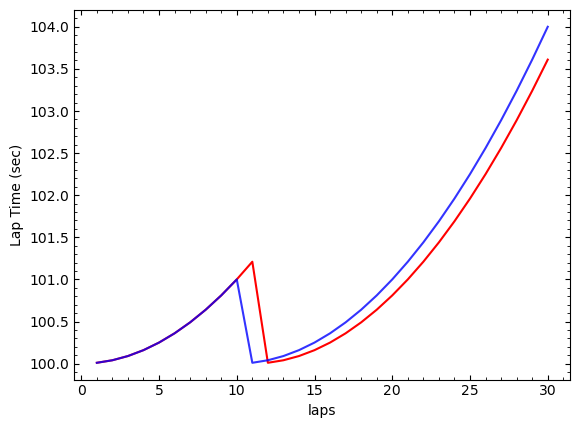

In [89]:
# IF number is negative Red Gains on Blue on track,
# IF number is positive Blue Gains on Red on track
redPitTimes = np.array([18.8])
bluePitTimes = np.array([18.9])


RaceTimeDif(30, CarParab, np.array([11, 100]), np.array([10,100])) - sum(bluePitTimes) + sum(redPitTimes)

Race Strategy Meeting Notes:

- 

does pre simulations inform setup

# F1 Telemery Analysis

### API Call for F1 telemery data